# Cybersecurity Intrusion
Using a dataset about [cyber intrusion](https://www.kaggle.com/datasets/dnkumars/cybersecurity-intrusion-detection-dataset) found on kaggle, we aim to build a model that classifies whether a network session is a cyber attack or normal activity.

We begin by importing neccessary libraries and loading the dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from pathlib import Path
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
                             accuracy_score, average_precision_score,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, RocCurveDisplay,
                             f1_score, fbeta_score, make_scorer,
                             precision_score, recall_score,
                             PrecisionRecallDisplay, roc_auc_score,
                             )
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

#sns theme setup
sns.set_theme(style="ticks", context="talk")

# Consts
RANDOM_STATE = 29
TARGET_COLUMN = "attack_detected"

# Load data
data_path = Path("..")/"data"/"cybersecurity_intrusion_data.csv"
raw_intrusion_df = pd.read_csv(data_path, keep_default_na=False) # Dataset has none as an actual field value, so keep it

## 1. Check the data

First we check that the data is loaded as expected looking at the head, tail, and shape of the data (rows & cols)

In [2]:
raw_intrusion_df

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0
...,...,...,...,...,...,...,...,...,...,...,...
9532,SID_09533,194,ICMP,3,226.049889,AES,0.517737,3,Chrome,0,1
9533,SID_09534,380,TCP,3,182.848475,None,0.408485,0,Chrome,0,0
9534,SID_09535,664,TCP,5,35.170248,AES,0.359200,1,Firefox,0,0
9535,SID_09536,406,TCP,4,86.664703,AES,0.537417,1,Chrome,1,0


* The data appears to be loaded correctly as the columns title and data appear correct top to bottom and the shape is as expected.
  
<br>
Next We'll look at column details and check for any missing or duplicate data

In [3]:
raw_intrusion_df.info()
print()
missing_data = pd.DataFrame([
    {
        "rows": len(raw_intrusion_df),
        "columns": raw_intrusion_df.shape[1],
        "missing_values": int(raw_intrusion_df.isna().sum().sum()), # Need both sum() to work
        "duplicate_rows": int(raw_intrusion_df.duplicated().sum()),
    }
])

display(missing_data.round(3))

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      9537 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB



,rows,columns,missing_values,duplicate_rows
0,9537,11,0,0


The raw dataset has 11 columns with no missing values or duplicate rows that appear in the dataset, so the only direct cleaning step in the final notebook is dropping **session_id** since that is a unique identifier and holds no predictive merit for the model to train with.

In [4]:
raw_intrusion_df.drop(columns=["session_id"], inplace=True)

raw_intrusion_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   network_packet_size  9537 non-null   int64  
 1   protocol_type        9537 non-null   str    
 2   login_attempts       9537 non-null   int64  
 3   session_duration     9537 non-null   float64
 4   encryption_used      9537 non-null   str    
 5   ip_reputation_score  9537 non-null   float64
 6   failed_logins        9537 non-null   int64  
 7   browser_type         9537 non-null   str    
 8   unusual_time_access  9537 non-null   int64  
 9   attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(3)
memory usage: 745.2 KB


<br>
We'll look at statistical data about the numeric features

In [5]:
raw_intrusion_df.describe().T

,count,mean,std,min,25%,50%,75%,max
network_packet_size,9537.0,500.430639,198.379364,64.000000,365.000000,499.000000,635.000000,1285.000000
login_attempts,9537.0,4.032086,1.963012,1.000000,3.000000,4.000000,5.000000,13.000000
session_duration,9537.0,792.745312,786.560144,0.500000,231.953006,556.277457,1105.380602,7190.392213
ip_reputation_score,9537.0,0.331338,0.177175,0.002497,0.191946,0.314778,0.453388,0.924299
failed_logins,9537.0,1.517773,1.033988,0.000000,1.000000,1.000000,2.000000,5.000000
unusual_time_access,9537.0,0.149942,0.357034,0.000000,0.000000,0.000000,0.000000,1.000000
attack_detected,9537.0,0.447101,0.497220,0.000000,0.000000,0.000000,1.000000,1.000000


* An interesting observation is the max **login_attempts** appear to be 13 and max **failed_logins** appear to be 5
* There appears to be a lot of deviation with **network_packet_size** and **session_duration**
* **ip_repuation_score** is on a 0 - 1 scale
* Here we see that some of the numeric data don't yeild useful stats such as attack_detected and unusual time access since they are treated as 0 or 1 flags.
<br>

## 3. EDA Visuals

We'll explore the data to understand our data. Our first look will be at our label **attack_detected** to see how much of our data consists of normal/attack


In [6]:
# Set up EDA df for visuals
label_map = {0: "Normal", 1: "Attack"}
eda_plot_df = raw_intrusion_df.copy()
eda_plot_df["attack_label"] = eda_plot_df[TARGET_COLUMN].map(label_map)
palette = {"Normal": "steelblue", "Attack": "firebrick",}


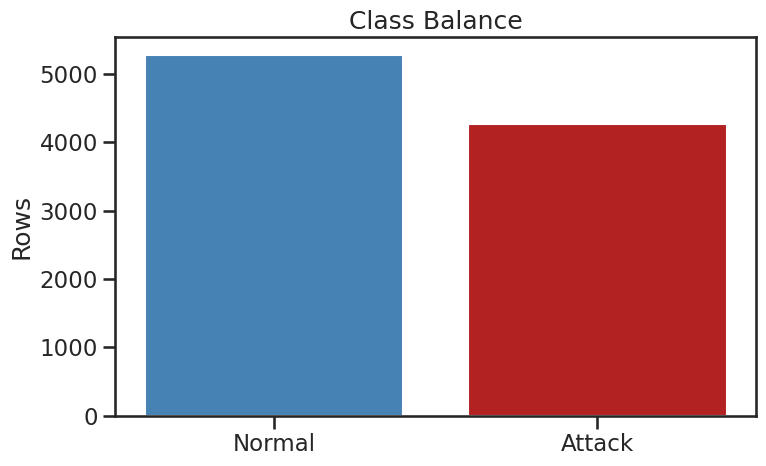

,normal count,attack count,attack rate
0,5273,4264,0.447101


In [7]:
# Create count plot visual
class_counts = eda_plot_df["attack_label"].value_counts().reindex(["Normal", "Attack"])
plt.figure(figsize=(8, 5))
plt.bar(class_counts.index, class_counts.values, color=["steelblue", "firebrick"])
plt.title("Class Balance")
plt.ylabel("Rows")
plt.xlabel("")
plt.tight_layout()
plt.show()

# Create summary for numbers
target_counts = pd.DataFrame([
    {
        "normal count": int((raw_intrusion_df[TARGET_COLUMN] == 0).sum()),
        "attack count": int((raw_intrusion_df[TARGET_COLUMN] == 1).sum()),
        "attack rate": raw_intrusion_df[TARGET_COLUMN].mean(),
    }
])
display(target_counts)

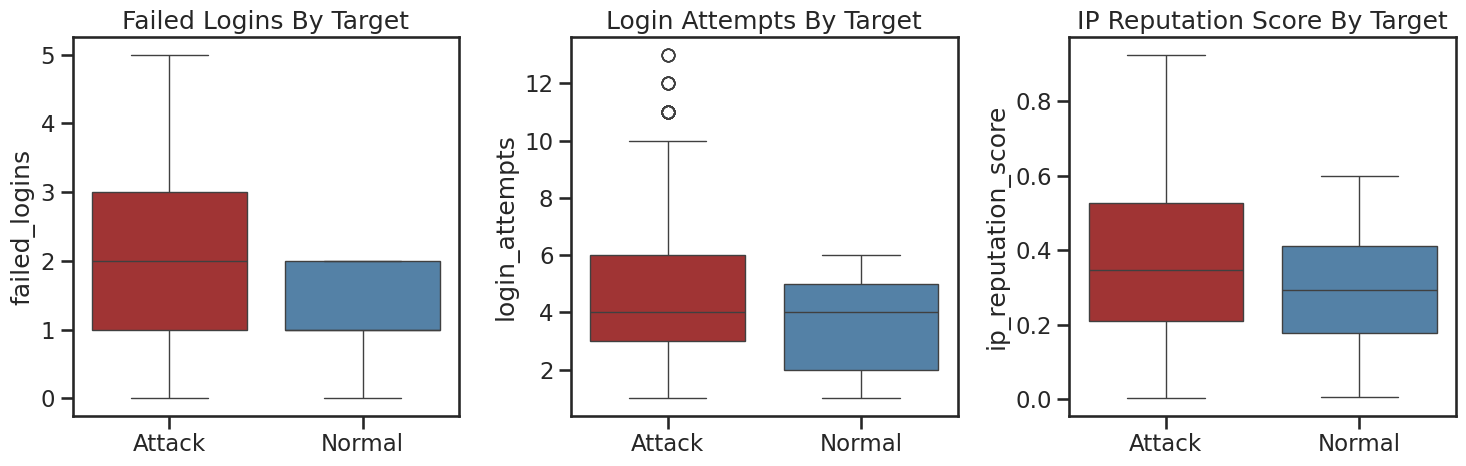

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=eda_plot_df, x="attack_label", y="failed_logins", ax=axes[0], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[0].set_title("Failed Logins By Target")
axes[0].set_xlabel("")
axes[0].set_ylabel("failed_logins")

sns.boxplot(data=eda_plot_df, x="attack_label", y="login_attempts", ax=axes[1], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[1].set_title("Login Attempts By Target")
axes[1].set_xlabel("")
axes[1].set_ylabel("login_attempts")

sns.boxplot(data=eda_plot_df, x="attack_label", y="ip_reputation_score", ax=axes[2], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
axes[2].set_title("IP Reputation Score By Target")
axes[2].set_xlabel("")
axes[2].set_ylabel("ip_reputation_score")

plt.tight_layout()
plt.show()

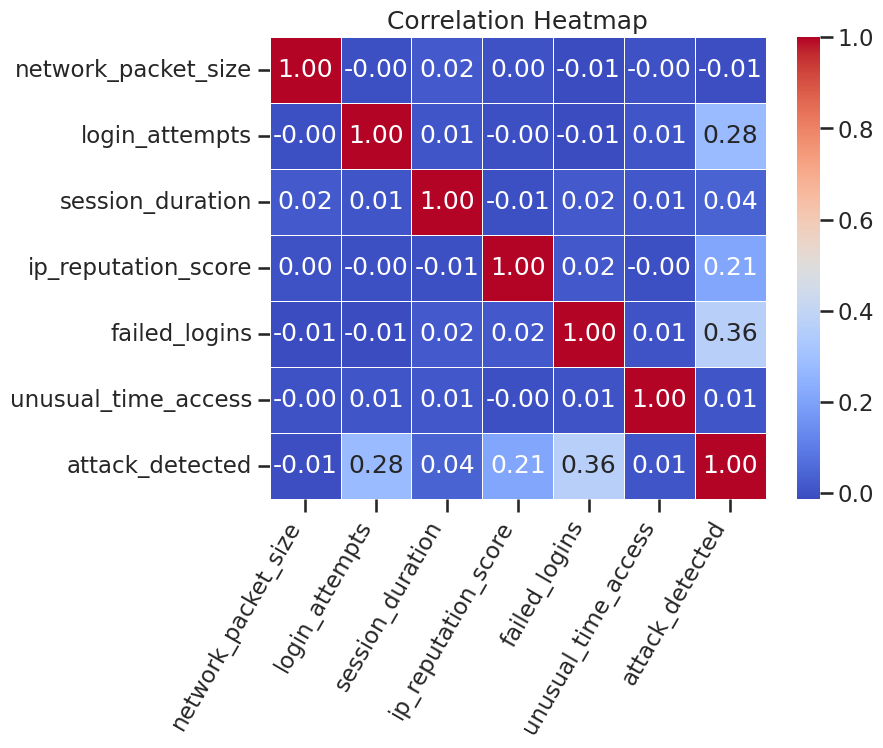

In [9]:
eda_heatmap_columns = [col for col in eda_plot_df.select_dtypes(include=["number"]).columns.tolist() if col != TARGET_COLUMN] + [TARGET_COLUMN]
plt.figure(figsize=(8,6))
sns.heatmap(eda_plot_df[eda_heatmap_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.xticks(rotation=60, ha="right")
plt.show()

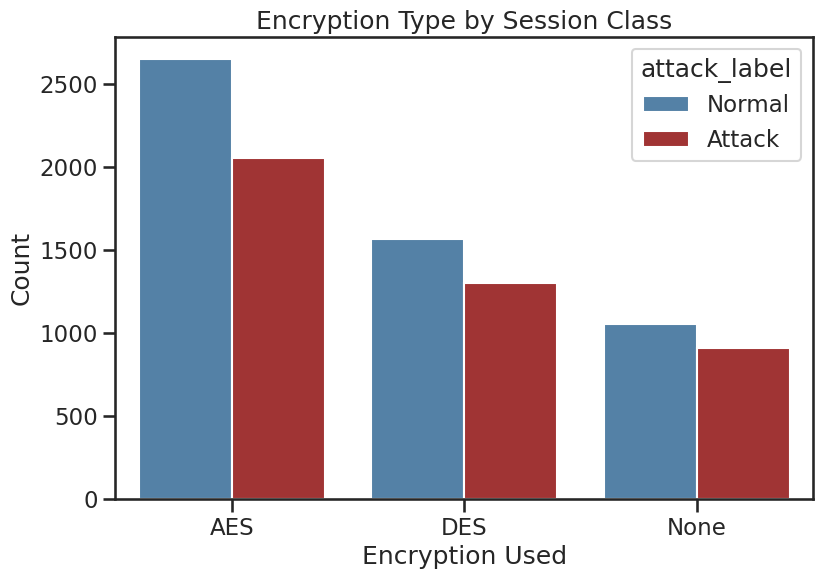

In [10]:
plt.figure(figsize=(9, 6))
sns.countplot(data=eda_plot_df, x="encryption_used", order=["AES", "DES", "None"], hue="attack_label", hue_order=["Normal", "Attack"], palette=palette)
plt.title("Encryption Type by Session Class")
plt.xlabel("Encryption Used")
plt.ylabel("Count")
plt.show()

## 4. Data Issue Discovered

During EDA, we found rows where `failed_logins > login_attempts`. This logically doesn't make sense as failed logins cannot exceed the attempted logins. In other words, you cannot fail more than you try.

In [11]:
# Configure data
invalid_rows = eda_plot_df.loc[raw_intrusion_df["failed_logins"] > raw_intrusion_df["login_attempts"]].copy()
valid_rows = eda_plot_df.loc[raw_intrusion_df["failed_logins"] <= raw_intrusion_df["login_attempts"]].copy()
eda_plot_df["failed_login_validity"] = np.where(eda_plot_df["failed_logins"] > eda_plot_df["login_attempts"], "Invalid", "Valid")

In [12]:
# Display sample of invalid failed login rows
print("Sample of invalid rows:")
display(
    invalid_rows[
        [
            "login_attempts",
            "failed_logins",
            "ip_reputation_score",
            "session_duration",
            "browser_type",
            "unusual_time_access",
            TARGET_COLUMN,
        ]
    ].head(5)
)

Sample of invalid rows:


,login_attempts,failed_logins,ip_reputation_score,session_duration,browser_type,unusual_time_access,attack_detected
17,1,2,0.136729,87.641002,Firefox,0,0
33,2,3,0.110269,1039.101186,Chrome,0,1
59,1,2,0.259419,989.889796,Edge,0,1
69,1,2,0.408654,1105.380602,Chrome,0,1
101,2,3,0.204681,294.584967,Chrome,0,1


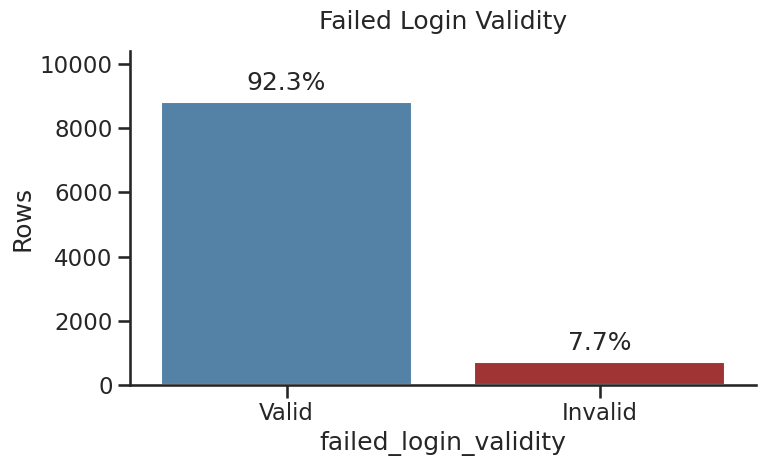

,valid rows,invalid rows,percent invalid,attack rate invalid rows,attack rate valid rows
0,8807,730,0.0765,0.7068,0.4256


In [13]:
# Display valid / invalid visual
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=eda_plot_df, x="failed_login_validity", hue="failed_login_validity", hue_order=["Valid", "Invalid"], palette={"Valid": "steelblue", "Invalid": "firebrick"})
max_count = eda_plot_df["failed_login_validity"].value_counts().max()
ax.set_ylim(0, max_count * 1.18)
plt.title("Failed Login Validity", pad=16)
plt.ylabel("Rows")
total_rows = len(eda_plot_df)
for p in ax.patches:
    height = p.get_height()
    pct = height / total_rows * 100
    ax.annotate(
        f"{pct:.1f}%",
        (p.get_x() + p.get_width() / 2, height), ha="center", va="bottom", xytext=(0, 5), textcoords="offset points")
sns.despine()
plt.tight_layout()
plt.show()

# Display summary of valid / invalid failed logins 
invalid_summary = pd.DataFrame([
    {
        "valid rows": len(valid_rows),
        "invalid rows": len(invalid_rows),
        "percent invalid": len(invalid_rows) / len(raw_intrusion_df),
        "attack rate invalid rows": invalid_rows[TARGET_COLUMN].mean(),
        "attack rate valid rows": raw_intrusion_df.loc[raw_intrusion_df["failed_logins"] <= raw_intrusion_df["login_attempts"], TARGET_COLUMN].mean(),
    }
])
display(invalid_summary.round(4))

* Different feature engineering strategies was performed for this by dropping invalid rows, imputing them by failed logins 1 less than login attempts for invalid rows, and creating ratios.... but all attempts resulted in degraded performance. For the final notebook, we kept the raw dataset as provided so the analysis stays faithful to the source data. However, this illogical finding limits the models effectiveness in a real world setting. 

## 5. Feature Engineering

The raw dataset is kept as provided and a few engineered features that had

The quick correlation check below is only used as a simple sanity check. The table focuses on the engineered features, while the heatmap compares the original numeric features, the engineered features, and the target together in one correlation matrix before model training.


Added engineered features: ['failed_login_reputation_score', 'login_attempt_reputation_score']


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected,failed_login_reputation_score,login_attempt_reputation_score
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1,1.213636,2.427272
1,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0,0.301569,0.904707
2,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1,2.217493,2.217493
3,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1,0.123267,0.493069
4,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0,0.109748,0.274369


Model df shape: (9537, 12)


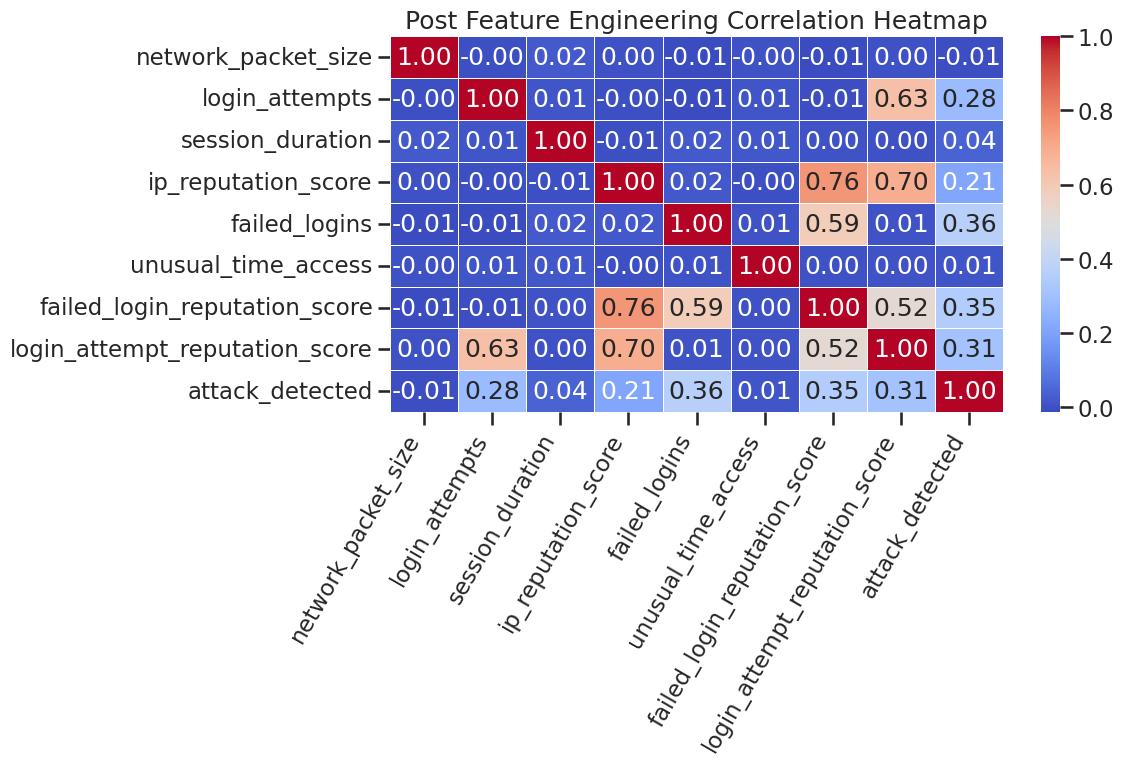

In [14]:
def feature_engineering(df):
    new_df = df.copy()

    new_df["failed_login_reputation_score"] = new_df["ip_reputation_score"] * (new_df["failed_logins"] + 1)
    new_df["login_attempt_reputation_score"] = new_df["login_attempts"] * new_df["ip_reputation_score"]

    return new_df


# Create df for model to use
model_df = feature_engineering(raw_intrusion_df)
new_feature_columns = [col for col in model_df.select_dtypes(include=["number"]).columns if col not in raw_intrusion_df.columns]

# Display model df with engineered features
print("Added engineered features:", new_feature_columns)
display(model_df.head())
print("Model df shape:", model_df.shape)

# Display heatmap correlation visual
engineer_heatmap_columns = [col for col in model_df.columns.tolist() if col != TARGET_COLUMN] + [TARGET_COLUMN]
numeric_corr_cols = model_df[engineer_heatmap_columns].corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_corr_cols, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Post Feature Engineering Correlation Heatmap")
plt.xlabel("")
plt.ylabel("")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Modeling Helpers

These helper functions keep the modeling workflow compact by separating preprocessing, model creation, evaluation, and charting from the main train/test workflow.


In [15]:
def build_preprocessor(X_train):
    # Separate numerical and categorical features
    numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
    categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("scaler", StandardScaler())]), numeric_features),
            ("cat", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), categorical_features),
        ],
        sparse_threshold=0.0,
    )


def build_models():
    return {
        "LogisticRegression": LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000,
        ),
        "DecisionTree": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            criterion="entropy",
            max_depth=5,
            min_samples_leaf=25,
            class_weight="balanced",
        ),
        "RandomForest": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_estimators=500,
            min_samples_leaf=2,
            n_jobs=1,
        ),
        "GradientBoosting": GradientBoostingClassifier(
            random_state=RANDOM_STATE,
            n_estimators=300,
            learning_rate=0.05,
            max_depth=3,
            min_samples_split=20,
            min_samples_leaf=10,
            subsample=0.8,
        ),
        "HistGradientBoosting": HistGradientBoostingClassifier(
            random_state=RANDOM_STATE,
            learning_rate=0.06,
            max_depth=5,
            max_leaf_nodes=31,
            min_samples_leaf=40,
            l2_regularization=1.0,
        ),
        "XGBoost": XGBClassifier(
            random_state=RANDOM_STATE,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            n_estimators=350,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_lambda=2.0,
            gamma=0.5,
            n_jobs=1,
        ),
    }


def evaluate_probabilities(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "f2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "avg_precision": average_precision_score(y_true, y_prob),
    }


def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    return {
        "accuracy": accuracy_score(y, y_pred),
        "precision": precision_score(y, y_pred, zero_division=0),
        "recall": recall_score(y, y_pred, zero_division=0),
        "f1": f1_score(y, y_pred, zero_division=0),
        "f2": fbeta_score(y, y_pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y, y_prob),
        "avg_precision": average_precision_score(y, y_prob),
    }


def plot_model_charts(model, X, y, title_prefix="Model"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    _, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    ConfusionMatrixDisplay.from_predictions(y, y_pred, display_labels=["Normal", "Attack"], ax=axes[0], cmap="Greens", colorbar=False)
    axes[0].set_title(f"{title_prefix} Confusion Matrix")

    PrecisionRecallDisplay.from_predictions(y, y_prob, ax=axes[1])
    axes[1].set_title(f"{title_prefix} Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1.02)
    axes[1].set_xticks(np.arange(0, 1.01, 0.2))
    axes[1].set_yticks(np.arange(0, 1.01, 0.2))
    axes[1].set_xticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[1].set_yticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[1].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[1].tick_params(axis="x", labelrotation=0)
    plt.setp(axes[1].get_xticklabels(), ha="center")
    axes[1].grid(True, which="major", alpha=0.25)
    axes[1].grid(True, which="minor", alpha=0.15)
    pr_legend = axes[1].legend(loc="lower center", bbox_to_anchor=(0.5, 0.03), fontsize=16, handlelength=1.8, handletextpad=0.4, borderpad=0.4)
    for line in pr_legend.get_lines():
        line.set_linewidth(1.25)

    RocCurveDisplay.from_predictions(y, y_prob, ax=axes[2])
    axes[2].set_title(f"{title_prefix} ROC Curve")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_xlim(0, 1)
    axes[2].set_ylim(0, 1.02)
    axes[2].set_xticks(np.arange(0, 1.01, 0.2))
    axes[2].set_yticks(np.arange(0, 1.01, 0.2))
    axes[2].set_xticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[2].set_yticks(np.arange(0, 1.01, 0.1), minor=True)
    axes[2].xaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[2].yaxis.set_major_formatter(FormatStrFormatter("%.1f"))
    axes[2].tick_params(axis="x", labelrotation=0)
    plt.setp(axes[2].get_xticklabels(), ha="center")
    axes[2].grid(True, which="major", alpha=0.25)
    axes[2].grid(True, which="minor", alpha=0.15)
    roc_legend = axes[2].legend(loc="lower center", bbox_to_anchor=(0.5, 0.03), fontsize=15, handlelength=1.8, handletextpad=0.4, borderpad=0.4)
    for line in roc_legend.get_lines():
        line.set_linewidth(1.25)

    plt.tight_layout()
    plt.show()


## 7. Train/Test Split


In [16]:
# Seperate target feature
X = model_df.drop(columns=[TARGET_COLUMN]).copy()
y = model_df[TARGET_COLUMN].astype(int).copy()

# Create 80/20 train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

# Display summary of train/test split
split_summary = pd.DataFrame([
    {
        "split": "train",
        "X shape": X_train.shape,
        "y shape": str(y_train.shape[0]),
        "attack proportion": y_train.mean(),
        "% of data": f"{len(X_train) / len(model_df):.0%}"
    },
    {
        "split": "test",
        "X shape": X_test.shape,
        "y shape": str(y_test.shape[0]),
        "attack proportion": y_test.mean(),
        "% of data": f"{len(X_test) / len(model_df):.0%}"

    },
])
display(split_summary.round(3))

,split,X shape,y shape,attack proportion,% of data
0,train,"(7629, 11)",7629,0.447,80%
1,test,"(1908, 11)",1908,0.447,20%


## 8. Model Comparison With Cross-Validation


In [17]:
# Build models and preprocessor
models = build_models()
preprocessor = build_preprocessor(X_train)

# Create cross validation stratified k-fold and scoring 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "f2": make_scorer(fbeta_score, beta=2),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

# Initialize containers
model_pipelines = {}
model_results = []

# Cross validate models with Startified K-fold and get scores
for name, model in models.items():
    # Create model pipelins and save them
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    model_pipelines[name] = pipeline

    # Get scores of cross validated model
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)

    # Average and standardize scores and save them
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    model_results.append(row)

# Display cross validation scores
cv_results = (pd.DataFrame(model_results).sort_values(by=["f2_mean", "recall_mean", "average_precision_mean"], ascending=False).reset_index(drop=True))
display(cv_results[[
    "model",
    "accuracy_mean",
    "f2_mean",
    "recall_mean",
    "roc_auc_mean",
    "f1_mean",
    "average_precision_mean",
    "precision_mean",
]].round(3))

,model,accuracy_mean,f2_mean,recall_mean,roc_auc_mean,f1_mean,average_precision_mean,precision_mean
0,GradientBoosting,0.892,0.799,0.761,0.884,0.863,0.913,0.996
1,XGBoost,0.889,0.796,0.758,0.888,0.859,0.915,0.992
2,RandomForest,0.890,0.796,0.758,0.887,0.861,0.915,0.996
3,DecisionTree,0.890,0.794,0.755,0.881,0.860,0.871,1.000
4,HistGradientBoosting,0.890,0.793,0.754,0.883,0.859,0.912,0.998
5,LogisticRegression,0.753,0.710,0.704,0.817,0.718,0.822,0.733


## 9. Final Model Choice

The final model is chosen from the cross-validation results on the training split.
The selected model is simply the top row from the cross-validation table based on the strongest F2 score in this workflow.


In [18]:
winner_name = cv_results.iloc[0]["model"]
winner_pipeline = model_pipelines[winner_name]
winner_pipeline.fit(X_train, y_train)
print(f"Selected model: {winner_name}")

Selected model: GradientBoosting


## 10. Final Test Performance


Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      1.00      0.92      1055
      Attack       1.00      0.78      0.88       853

    accuracy                           0.90      1908
   macro avg       0.93      0.89      0.90      1908
weighted avg       0.92      0.90      0.90      1908



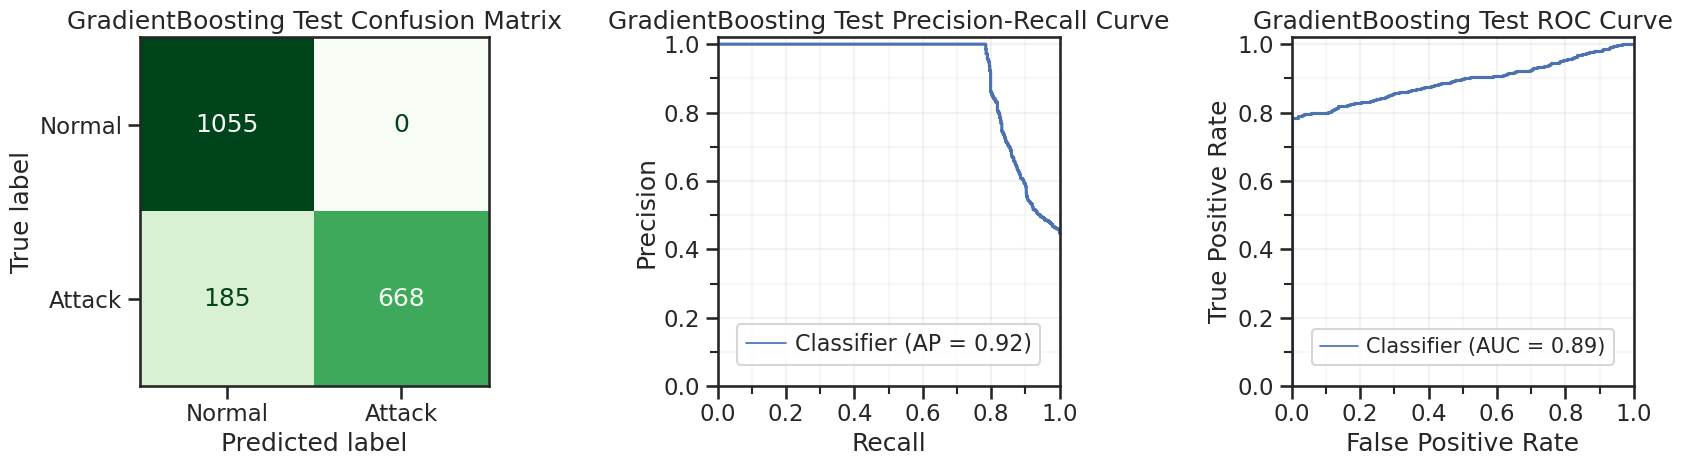

,accuracy,precision,recall,f1,f2,roc_auc,avg_precision
0,0.903,1.0,0.783,0.878,0.819,0.892,0.921


In [19]:
y_test_pred = winner_pipeline.predict(X_test)
y_test_prob = winner_pipeline.predict_proba(X_test)[:, 1]
test_metrics = evaluate_model(winner_pipeline, X_test, y_test)
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=["Normal", "Attack"]))
plot_model_charts(winner_pipeline, X_test, y_test, title_prefix=f"{winner_name} Test")
display(pd.DataFrame([test_metrics]).round(3))

## 11. Misclassified Test Sessions

This small table shows a few test examples the final model predicted incorrectly, which helps explain where the model still makes mistakes.


In [20]:
label_map = {0: "Normal", 1: "Attack"}
misclassified_rows = y_test != y_test_pred
misclassified_columns = [
    "network_packet_size",
    "protocol_type",
    "login_attempts",
    "session_duration",
    "encryption_used",
    "ip_reputation_score",
    "failed_logins",
    "browser_type",
    "unusual_time_access",
]

misclassified_test = X_test.loc[misclassified_rows, misclassified_columns].copy()
misclassified_test["y_true"] = y_test.loc[misclassified_rows].map(label_map)
misclassified_test["y_pred"] = pd.Series(y_test_pred, index=X_test.index).loc[misclassified_rows].map(label_map)
misclassified_test["attack_probability"] = pd.Series(y_test_prob, index=X_test.index).loc[misclassified_rows]

print(f"Misclassified sessions: {misclassified_rows.sum()}")
display(misclassified_test.reset_index(drop=True).head(10).round(4))


Misclassified sessions: 185


,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,y_true,y_pred,attack_probability
0,724,TCP,4,521.6395,AES,0.1050,2,Chrome,0,Attack,Normal,0.1311
1,530,TCP,5,1169.5081,DES,0.3755,2,Chrome,0,Attack,Normal,0.2051
2,130,ICMP,4,1021.4223,AES,0.5407,2,Chrome,0,Attack,Normal,0.1485
3,506,UDP,3,78.4550,AES,0.3099,1,Chrome,0,Attack,Normal,0.1786
4,235,UDP,5,1445.1720,None,0.3236,0,Edge,0,Attack,Normal,0.2636
5,316,UDP,3,420.8243,DES,0.1010,0,Chrome,0,Attack,Normal,0.1085
6,668,TCP,4,460.2492,AES,0.2030,1,Chrome,0,Attack,Normal,0.1779
7,795,UDP,6,328.9642,None,0.2601,1,Chrome,0,Attack,Normal,0.1704
8,608,UDP,5,2752.6010,AES,0.0982,0,Chrome,0,Attack,Normal,0.2569
9,426,TCP,5,928.2326,None,0.5665,1,Chrome,1,Attack,Normal,0.1847


## 12. Threshold Sensitivity For GradientBoosting

This section compares the default `0.50` threshold to a lower `0.30` threshold for the winning `GradientBoosting` model using cross-validated predicted probabilities on the training split. Lowering the threshold is a fair way to test whether the model can catch more attacks, but it usually trades away precision.

The final reported test model in this notebook uses threshold `0.50`; the `0.30` row is included only to show the recall tradeoff without tuning directly on the test split.


In [21]:
thresholds = [0.50, 0.30]
cross_validated_probabilities = cross_val_predict(
    winner_pipeline,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=1,
)[:, 1]

recall_threshold_rows = []
threshold_tradeoff_rows = []
for threshold in thresholds:
    y_threshold_pred = (cross_validated_probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_train, y_threshold_pred, labels=[0, 1]).ravel()
    recall_threshold_rows.append({
        "model": winner_name,
        "threshold": threshold,
        **evaluate_probabilities(y_train, cross_validated_probabilities, threshold),
    })
    threshold_tradeoff_rows.append({
        "model": winner_name,
        "threshold": threshold,
        "attacks_caught": int(tp),
        "missed_attacks": int(fn),
        "predicted_attack_alerts": int(tp + fp),
        "false_alarms": int(fp),
    })

recall_sensitivity = pd.DataFrame(recall_threshold_rows).sort_values(by=["threshold"], ascending=[False]).reset_index(drop=True)
threshold_tradeoff = pd.DataFrame(threshold_tradeoff_rows).sort_values(by=["threshold"], ascending=[False]).reset_index(drop=True)
default_threshold_tradeoff = threshold_tradeoff.loc[threshold_tradeoff["threshold"] == 0.50].iloc[0]
threshold_tradeoff["extra_attacks_caught_vs_0.50"] = threshold_tradeoff["attacks_caught"] - default_threshold_tradeoff["attacks_caught"]
threshold_tradeoff["extra_false_alarms_vs_0.50"] = threshold_tradeoff["false_alarms"] - default_threshold_tradeoff["false_alarms"]
threshold_tradeoff["extra_alerts_vs_0.50"] = threshold_tradeoff["predicted_attack_alerts"] - default_threshold_tradeoff["predicted_attack_alerts"]

display(
    recall_sensitivity[[
        "model",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "f2",
        "avg_precision",
    ]].round(3)
)

display(
    threshold_tradeoff[[
        "model",
        "threshold",
        "attacks_caught",
        "missed_attacks",
        "false_alarms",
        "extra_attacks_caught_vs_0.50",
        "extra_false_alarms_vs_0.50",
    ]]
)

,model,threshold,accuracy,precision,recall,f1,f2,avg_precision
0,GradientBoosting,0.5,0.892,0.996,0.761,0.863,0.799,0.913
1,GradientBoosting,0.3,0.880,0.952,0.770,0.851,0.800,0.913


,model,threshold,attacks_caught,missed_attacks,false_alarms,extra_attacks_caught_vs_0.50,extra_false_alarms_vs_0.50
0,GradientBoosting,0.5,2596,815,11,0,0
1,GradientBoosting,0.3,2626,785,133,30,122


## 13. Generalization Check

Instead of showing lots of training output, this table gives one compact comparison between cross-validation, training, and test performance for the final reported model. The classification metrics below reflect the pipeline's default `predict()` behavior, which corresponds to the standard `0.50` threshold.


In [22]:
train_metrics = evaluate_model(winner_pipeline, X_train, y_train)
best_cv_row = cv_results.loc[cv_results["model"] == winner_name].iloc[0]
generalization_table = pd.DataFrame([
    {
        "split": "Cross-Validation Mean",
        "model": winner_name,
        "accuracy": best_cv_row["accuracy_mean"],
        "precision": best_cv_row["precision_mean"],
        "recall": best_cv_row["recall_mean"],
        "f1": best_cv_row["f1_mean"],
        "f2": best_cv_row["f2_mean"],
        "roc_auc": best_cv_row["roc_auc_mean"],
        "avg_precision": best_cv_row["average_precision_mean"],
    },
    {
        "split": "Train",
        "model": winner_name,
        "accuracy": train_metrics["accuracy"],
        "precision": train_metrics["precision"],
        "recall": train_metrics["recall"],
        "f1": train_metrics["f1"],
        "f2": train_metrics["f2"],
        "roc_auc": train_metrics["roc_auc"],
        "avg_precision": train_metrics["avg_precision"],
    },
    {
        "split": "Test",
        "model": winner_name,
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "f2": test_metrics["f2"],
        "roc_auc": test_metrics["roc_auc"],
        "avg_precision": test_metrics["avg_precision"],
    },
])

display(generalization_table[[
    "split",
    "model",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "f2",
    "roc_auc",
    "avg_precision",
]].round(4))


,split,model,accuracy,precision,recall,f1,f2,roc_auc,avg_precision
0,Cross-Validation Mean,GradientBoosting,0.8917,0.9958,0.7611,0.8627,0.7987,0.8843,0.9131
1,Train,GradientBoosting,0.8945,1.0000,0.7640,0.8662,0.8018,0.9531,0.9587
2,Test,GradientBoosting,0.9030,1.0000,0.7831,0.8784,0.8186,0.8923,0.9205


## 14. Most Important Features

Following the class material, this ranking uses `RandomForestClassifier.feature_importances_` on the training split and then aggregates one-hot encoded columns back to their original feature names.


,ranking_model,fit_split,feature,importance
0,RandomForest,Train,failed_logins,0.2425
1,RandomForest,Train,login_attempts,0.1771
2,RandomForest,Train,ip_reputation_score,0.1587
3,RandomForest,Train,failed_login_reputation_score,0.1119
4,RandomForest,Train,login_attempt_reputation_score,0.1021
5,RandomForest,Train,session_duration,0.0675
6,RandomForest,Train,network_packet_size,0.0618
7,RandomForest,Train,browser_type,0.0421
8,RandomForest,Train,encryption_used,0.0159
9,RandomForest,Train,protocol_type,0.0133


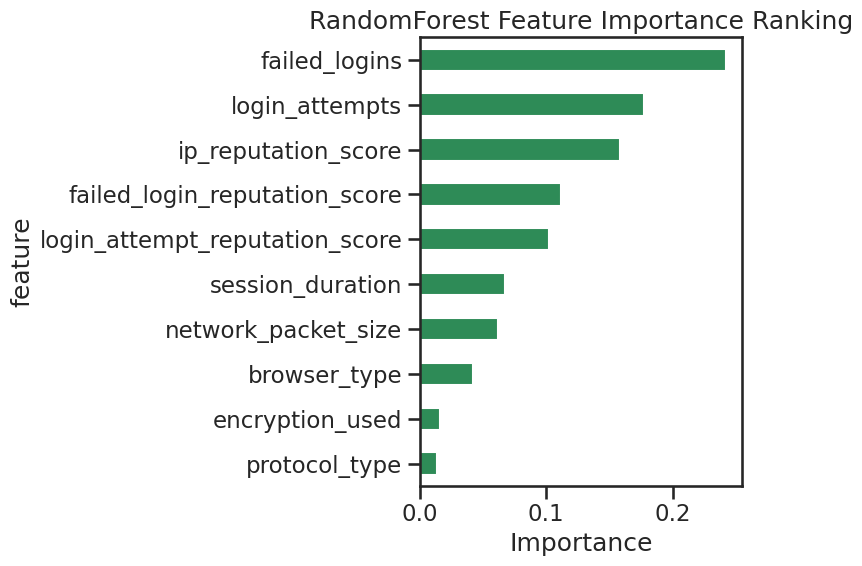

In [23]:
importance_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=500, n_jobs=1)),
])
importance_pipeline.fit(X_train, y_train)

encoded_feature_names = importance_pipeline.named_steps["preprocessor"].get_feature_names_out()
encoded_importances = importance_pipeline.named_steps["model"].feature_importances_

def collapse_feature_name(encoded_name):
    clean_name = encoded_name.replace("num__", "").replace("cat__", "")
    for column in X_train.columns:
        if clean_name == column or clean_name.startswith(f"{column}_"):
            return column
    return clean_name

importance_df = (
    pd.DataFrame({
        "feature": [collapse_feature_name(name) for name in encoded_feature_names],
        "importance": encoded_importances,
    })
    .groupby("feature", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

importance_display = importance_df.copy()
importance_display.insert(0, "ranking_model", "RandomForest")
importance_display.insert(1, "fit_split", "Train")

display(importance_display.round(4))

importance_df.sort_values("importance", ascending=True).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(8, 6),
    legend=False,
    color="seagreen",
)
plt.title("RandomForest Feature Importance Ranking")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


## 15. Final Result Summary

This is the compact summary to use on a showcase slide or poster screen. The threshold column shows the final reported setting.


In [24]:
final_summary = pd.DataFrame([
    {
        "model": winner_name,
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f2": test_metrics["f2"],
        "roc_auc": test_metrics["roc_auc"],
        "top_3_features": ", ".join(importance_df["feature"].head(3).tolist()),
    }
])

display(final_summary.round(4))


,model,accuracy,precision,recall,f2,roc_auc,top_3_features
0,GradientBoosting,0.903,1.0,0.7831,0.8186,0.8923,"failed_logins, login_attempts, ip_reputation_s..."


## 16. Final Takeaways

- The strongest default-threshold model in this workflow is the top row in the cross-validation comparison table.
- `LogisticRegression` provides the simple baseline model for comparison against the stronger tree-based models.
- For `GradientBoosting`, the lower-threshold row is useful as a recall-first operating point, but it is evaluated from training-set cross-validation rather than test-set tuning.
- The class-style feature ranking points to the strongest original features after aggregating one-hot encoded columns back together.
- The engineered features help a little, but the dataset is still feature-limited.
- The dataset contains logically inconsistent rows, so the results should be presented with that limitation in mind.
